---
title: "The Relationship Between Depth and Goaltending"
format:
  html:
    code-fold: true
    code-tools: true
    embed-resources: true
---

# Depth vs Goaltending: An Exploratory Analysis

This notebook explores the relationship between team depth (measured by TDI) and goaltending performance (measured by Goals Saved Above Expected, or GSAx). The central hypothesis is that **depth and goaltending compensate for each other**: teams with better depth require less goalie heroics to win, while shallow teams rely more heavily on goaltending to steal games.

We'll explore this relationship from multiple angles:
- How does goaltending performance differ across different types of wins?
- What is the functional relationship between depth advantage and required goalie advantage?
- Do teams have persistent "identities" (depth-driven vs goalie-dependent)?
- Has this relationship changed over time?
- Are there non-linear effects or thresholds?

## Data Notes

We're working with matchup-level data where each game contributes one observation from the winner's perspective. Our key variables:

- **GSAx (Goals Saved Above Expected)**: xGoals against - actual goals against (positive = good goaltending)
- **Depth**: TDI factor scores from the latent variable model
- **Depth differential**: Winner depth - Loser depth
- **GSAx differential**: Winner GSAx - Loser GSAx

In [22]:
# ----------------------------------------------------------------------
# SETUP
# ----------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# Brand styling
mpl.rcParams['font.family'] = 'Charter'
col_blue_pale = '#3B4B64'
col_blue_dark = '#041E42'
col_oil_orange = '#FF4C00'
col_gray = '#9AA3AF'

# Data paths
DATA_PATH = "/Users/dwiwad/dev/hockey_site/data/total-depth-index/all_seasons"

print("Setup complete. Using Charter font.")

Setup complete. Using Charter font.


In [23]:
# ----------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------

# Main dataset with TDI scores
data = pd.read_csv(f"{DATA_PATH}/final_data_20102025.csv")

# Schedule data for home/away and goals
schedule = pd.read_csv(f"{DATA_PATH}/all_games_meta_20102025.csv")

# Ensure consistent types
data['season'] = data['season'].astype(str)
data['game_id'] = data['game_id'].astype(int)
schedule['season'] = schedule['season'].astype(str)
schedule['game_id'] = schedule['id'].astype(int)

print(f"Loaded {len(data):,} team-game observations")
print(f"Loaded {len(schedule):,} games from schedule")
print(f"Seasons: {data['season'].min()} to {data['season'].max()}")

Loaded 38,394 team-game observations
Loaded 20,687 games from schedule
Seasons: 20102011 to 20242025


## Calculating Goals Saved Above Expected (GSAx)

GSAx is calculated as: **xGoals Against - Actual Goals Against**

For the home team's goalie:
- xGoals Against = away team's xGoals
- Goals Against = away team's actual goals
- GSAx_home = xgoal_away - away_goals

A positive GSAx means the goalie performed better than expected (saved more than predicted).
A negative GSAx means the goalie underperformed (allowed more than predicted).

We'll extract actual goals from the schedule data and merge it with our depth data.

In [24]:
# ----------------------------------------------------------------------
# EXTRACT GOALS FROM SCHEDULE
# ----------------------------------------------------------------------

goals_data = schedule[['game_id', 'season',
                       'homeTeam.abbrev', 'awayTeam.abbrev',
                       'homeTeam.score', 'awayTeam.score']].copy()

goals_data.columns = ['game_id', 'season', 'home_abbrev', 'away_abbrev',
                      'home_goals', 'away_goals']

# Standardize abbreviations
goals_data['home_abbrev'] = goals_data['home_abbrev'].str.upper()
goals_data['away_abbrev'] = goals_data['away_abbrev'].str.upper()

# Create a long-format dataset with one row per team-game
home_data = data.merge(
    goals_data[['game_id', 'season', 'home_abbrev', 'home_goals', 'away_goals']],
    on=['game_id', 'season'],
    how='inner'
)
home_data = home_data[home_data['teamAbbrev'] == home_data['home_abbrev']].copy()
home_data['is_home'] = 1

away_data = data.merge(
    goals_data[['game_id', 'season', 'away_abbrev', 'home_goals', 'away_goals']],
    on=['game_id', 'season'],
    how='inner'
)
away_data = away_data[away_data['teamAbbrev'] == away_data['away_abbrev']].copy()
away_data['is_home'] = 0

# Combine
combined = pd.concat([
    home_data.assign(
        team_goals=home_data['home_goals'],
        opp_goals=home_data['away_goals']
    ),
    away_data.assign(
        team_goals=away_data['away_goals'],
        opp_goals=away_data['home_goals']
    )
], ignore_index=True)

# We need opponent xGoal - opponent actual goals
# Team A's goalie faces xGoals generated BY OPPONENT
# We have each team's xGoal (what they generated), not what they faced

# Create matchup-level data
matchup_data = home_data.merge(
    away_data[['game_id', 'season', 'teamAbbrev', 'tdi_factor', 'xgoal', 'outcome']],
    on=['game_id', 'season'],
    how='inner',
    suffixes=('_home', '_away')
)

# Now calculate GSAx properly
# Home goalie faces away team's xGoals, allows away_goals
matchup_data['gsax_home'] = matchup_data['xgoal_away'] - matchup_data['away_goals']
# Away goalie faces home team's xGoals, allows home_goals  
matchup_data['gsax_away'] = matchup_data['xgoal_home'] - matchup_data['home_goals']

# Determine winner
matchup_data['home_win'] = (matchup_data['home_goals'] > matchup_data['away_goals']).astype(int)

print(f"Created {len(matchup_data):,} matchup observations")
print(f"Games with complete data: {matchup_data['game_id'].nunique():,}")

Created 19,197 matchup observations
Games with complete data: 19,197


## Reshaping to Winner/Loser Perspective

For analysis, it's often more intuitive to think about games from the winner's perspective:
- What was the winner's depth advantage over the loser?
- What was the winner's goalie advantage over the loser?

This allows us to ask: when depth advantage is low, how much goalie advantage is needed to win?

In [25]:
# ----------------------------------------------------------------------
# WINNER/LOSER PERSPECTIVE
# ----------------------------------------------------------------------

# Create winner/loser variables
matchup_data['winner_depth'] = np.where(
    matchup_data['home_win'] == 1,
    matchup_data['tdi_factor_home'],
    matchup_data['tdi_factor_away']
)

matchup_data['loser_depth'] = np.where(
    matchup_data['home_win'] == 1,
    matchup_data['tdi_factor_away'],
    matchup_data['tdi_factor_home']
)

matchup_data['winner_gsax'] = np.where(
    matchup_data['home_win'] == 1,
    matchup_data['gsax_home'],
    matchup_data['gsax_away']
)

matchup_data['loser_gsax'] = np.where(
    matchup_data['home_win'] == 1,
    matchup_data['gsax_away'],
    matchup_data['gsax_home']
)

# Calculate differentials
matchup_data['depth_diff'] = matchup_data['winner_depth'] - matchup_data['loser_depth']
matchup_data['gsax_diff'] = matchup_data['winner_gsax'] - matchup_data['loser_gsax']

# Categorize win types by depth differential
def categorize_depth_win(depth_diff):
    if depth_diff >= 0.05:
        return 'High-depth win'
    elif depth_diff <= -0.05:
        return 'Low-depth win'
    else:
        return 'Equal-depth'
        
matchup_data['win_type'] = matchup_data['depth_diff'].apply(categorize_depth_win)

# Game type (regular season vs playoffs)
matchup_data['game_type'] = matchup_data['game_id'].astype(str).str[4:6]
matchup_data['game_type_label'] = matchup_data['game_type'].map({
    '02': 'Regular Season',
    '03': 'Playoffs'
})

print("\nWin type distribution:")
print(matchup_data['win_type'].value_counts())
print("\nGame type distribution:")
print(matchup_data['game_type_label'].value_counts())


Win type distribution:
win_type
Low-depth win     9381
High-depth win    9307
Equal-depth        509
Name: count, dtype: int64

Game type distribution:
game_type_label
Regular Season    17840
Playoffs           1357
Name: count, dtype: int64


## Descriptive Statistics: Understanding the Distributions

Before testing our hypothesis, let's understand the basic distributions of our key variables.

### Questions to answer:
1. What does the overall distribution of GSAx look like?
2. Is GSAx normally distributed or skewed?
3. What are typical depth differentials in NHL games?
4. How often do low-depth teams actually win?

In [26]:
# ----------------------------------------------------------------------
# DESCRIPTIVE STATISTICS
# ----------------------------------------------------------------------

# Overall GSAx statistics
print("=" * 60)
print("GOALS SAVED ABOVE EXPECTED (GSAx) - DESCRIPTIVE STATISTICS")
print("=" * 60)

print("\nWinner GSAx:")
print(matchup_data['winner_gsax'].describe())

print("\nLoser GSAx:")
print(matchup_data['loser_gsax'].describe())

print("\nGSAx Differential (Winner - Loser):")
print(matchup_data['gsax_diff'].describe())

# Depth statistics
print("\n" + "=" * 60)
print("DEPTH DIFFERENTIAL - DESCRIPTIVE STATISTICS")
print("=" * 60)
print(matchup_data['depth_diff'].describe())

# Win type statistics
print("\n" + "=" * 60)
print("GSAx DIFFERENTIAL BY WIN TYPE")
print("=" * 60)

win_type_stats = matchup_data.groupby('win_type')['gsax_diff'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(3)
win_type_stats['se'] = (win_type_stats['std'] / np.sqrt(win_type_stats['count'])).round(3)

print(win_type_stats)

# Correlation
print("\n" + "=" * 60)
print("CORRELATION: DEPTH DIFFERENTIAL vs GSAx DIFFERENTIAL")
print("=" * 60)
corr = matchup_data[['depth_diff', 'gsax_diff']].corr().iloc[0, 1]
print(f"Pearson r = {corr:.4f}")

# Test significance
from scipy.stats import pearsonr
r, p = pearsonr(matchup_data['depth_diff'].dropna(),
                matchup_data['gsax_diff'].dropna())

GOALS SAVED ABOVE EXPECTED (GSAx) - DESCRIPTIVE STATISTICS

Winner GSAx:
count    19197.000000
mean         0.788920
std          1.269995
min         -4.993881
25%         -0.040381
50%          0.797976
75%          1.632334
max          8.564516
Name: winner_gsax, dtype: float64

Loser GSAx:
count    19197.000000
mean        -0.878996
std          1.461920
min         -7.268434
25%         -1.798612
50%         -0.843135
75%          0.096335
max          5.296014
Name: loser_gsax, dtype: float64

GSAx Differential (Winner - Loser):
count    19197.000000
mean         1.667916
std          1.598263
min         -5.301087
25%          0.593998
50%          1.555232
75%          2.665818
max         12.221153
Name: gsax_diff, dtype: float64

DEPTH DIFFERENTIAL - DESCRIPTIVE STATISTICS
count    19197.000000
mean        -0.014186
std          1.440166
min         -5.951842
25%         -0.973748
50%         -0.009103
75%          0.964145
max          5.118609
Name: depth_diff, dtype: floa

## Visualizing the Distributions

Let's visualize what we just calculated. We'll look at:
1. Overall GSAx differential distribution
2. GSAx differential by win type
3. The relationship between depth and GSAx

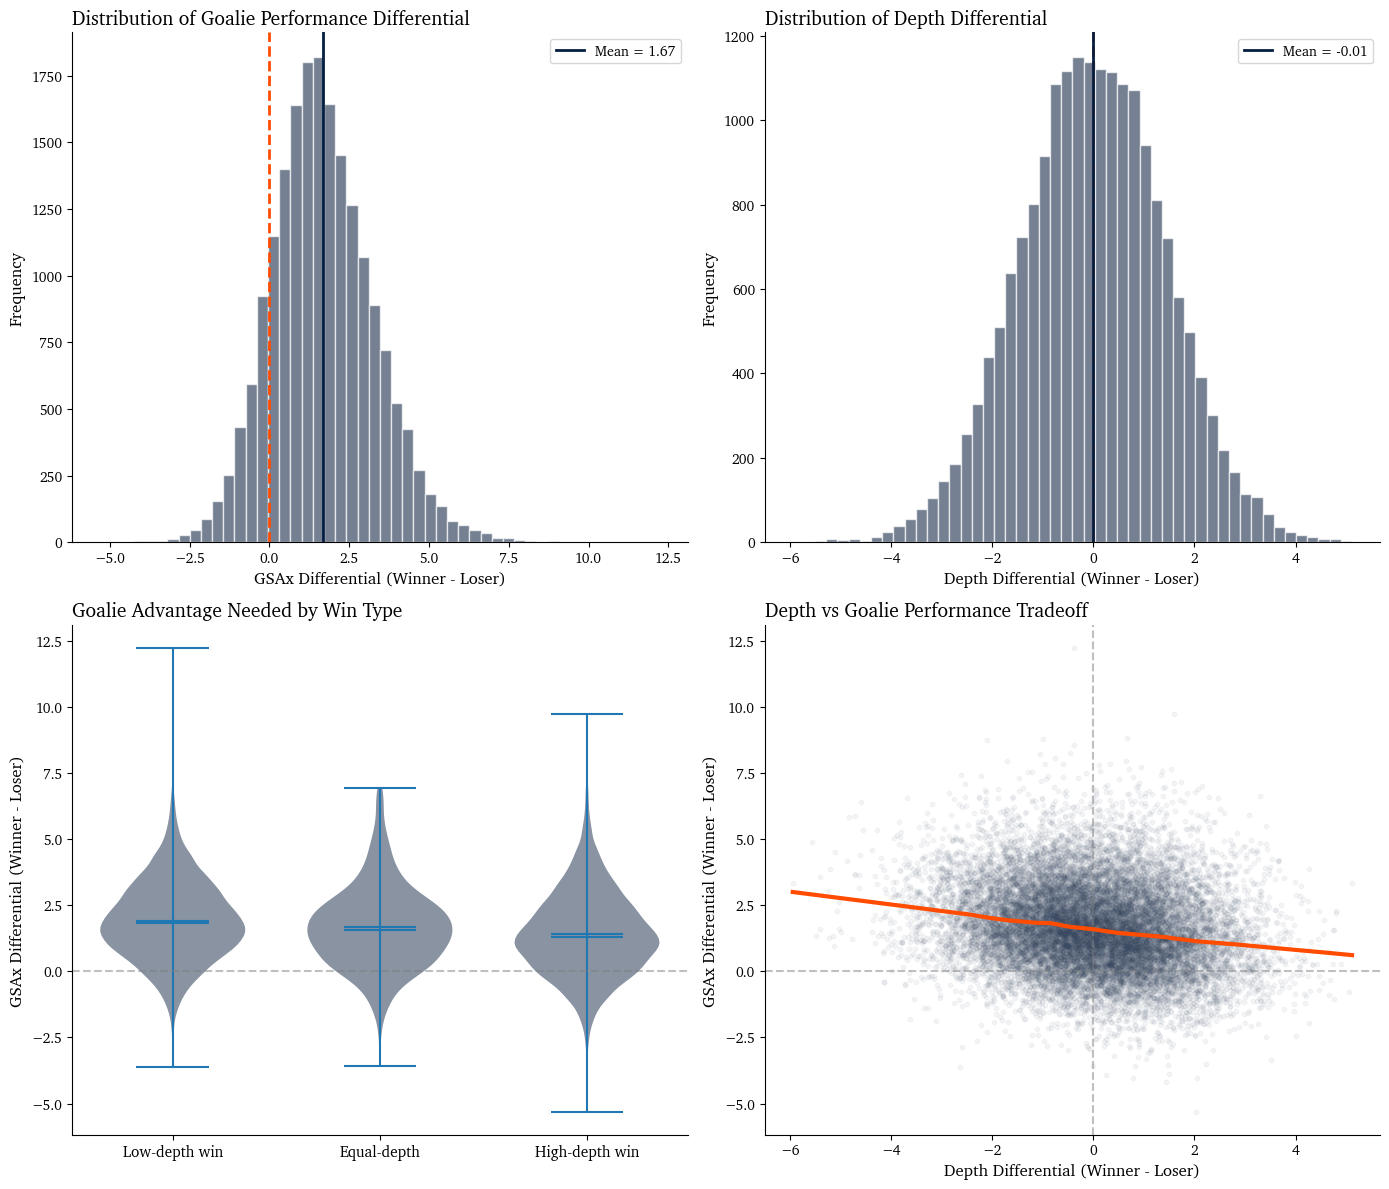


Key observation: There appears to be a NEGATIVE relationship
As depth advantage increases, the required goalie advantage DECREASES


In [27]:
# ----------------------------------------------------------------------
# DISTRIBUTION VISUALIZATIONS
# ----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Overall GSAx differential distribution
ax = axes[0, 0]
ax.hist(matchup_data['gsax_diff'].dropna(), bins=50,
        color=col_blue_pale, alpha=0.7, edgecolor='white')
ax.axvline(0, color=col_oil_orange, linestyle='--', linewidth=2)
ax.axvline(matchup_data['gsax_diff'].mean(), color=col_blue_dark,
           linestyle='-', linewidth=2, label=f"Mean = {matchup_data['gsax_diff'].mean():.2f}")
ax.set_xlabel('GSAx Differential (Winner - Loser)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Goalie Performance Differential',
             fontsize=14, weight='bold', loc='left')
ax.legend()
sns.despine()

# 2. Depth differential distribution
ax = axes[0, 1]
ax.hist(matchup_data['depth_diff'].dropna(), bins=50,
        color=col_blue_pale, alpha=0.7, edgecolor='white')
ax.axvline(0, color=col_oil_orange, linestyle='--', linewidth=2)
ax.axvline(matchup_data['depth_diff'].mean(), color=col_blue_dark,
           linestyle='-', linewidth=2, label=f"Mean = {matchup_data['depth_diff'].mean():.2f}")
ax.set_xlabel('Depth Differential (Winner - Loser)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Depth Differential',
             fontsize=14, weight='bold', loc='left')
ax.legend()
sns.despine()

# 3. GSAx by win type (violin plot)
ax = axes[1, 0]
win_type_order = ['Low-depth win', 'Equal-depth', 'High-depth win']
plot_data = matchup_data[matchup_data['win_type'].isin(win_type_order)].copy()

parts = ax.violinplot(
    [plot_data[plot_data['win_type'] == wt]['gsax_diff'].dropna()
     for wt in win_type_order],
    positions=[0, 1, 2],
    widths=0.7,
    showmeans=True,
    showmedians=True
)

for pc in parts['bodies']:
    pc.set_facecolor(col_blue_pale)
    pc.set_alpha(0.6)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(win_type_order, fontsize=11)
ax.set_ylabel('GSAx Differential (Winner - Loser)', fontsize=12)
ax.set_title('Goalie Advantage Needed by Win Type',
             fontsize=14, weight='bold', loc='left')
sns.despine()

# 4. Scatter: depth diff vs gsax diff
ax = axes[1, 1]
ax.scatter(matchup_data['depth_diff'], matchup_data['gsax_diff'],
           alpha=0.05, s=10, color=col_blue_pale)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Add LOESS smooth
depth_clean = matchup_data[['depth_diff', 'gsax_diff']].dropna()
smoothed = lowess(depth_clean['gsax_diff'], depth_clean['depth_diff'], frac=0.2)
ax.plot(smoothed[:, 0], smoothed[:, 1], color=col_oil_orange, linewidth=3)

ax.set_xlabel('Depth Differential (Winner - Loser)', fontsize=12)
ax.set_ylabel('GSAx Differential (Winner - Loser)', fontsize=12)
ax.set_title('Depth vs Goalie Performance Tradeoff',
             fontsize=14, weight='bold', loc='left')
sns.despine()

plt.tight_layout()
plt.show()

print("\nKey observation: There appears to be a NEGATIVE relationship")
print("As depth advantage increases, the required goalie advantage DECREASES")

## Hypothesis Test 1: Do Low-Depth Wins Require More Goalie Performance?

**Null Hypothesis**: There is no difference in GSAx differential across win types

**Alternative Hypothesis**: Low-depth wins have higher GSAx differentials than high-depth wins

We'll test this with:
1. One-way ANOVA (are there any differences?)
2. Post-hoc pairwise t-tests (which pairs differ?)
3. Effect sizes (how big are the differences?)

In [28]:
# ----------------------------------------------------------------------
# HYPOTHESIS TEST 1: ANOVA AND POST-HOC COMPARISONS
# ----------------------------------------------------------------------

from scipy.stats import f_oneway, ttest_ind

# Prepare data
low_depth = matchup_data[matchup_data['win_type'] == 'Low-depth win']['gsax_diff'].dropna()
equal_depth = matchup_data[matchup_data['win_type'] == 'Equal-depth']['gsax_diff'].dropna()
high_depth = matchup_data[matchup_data['win_type'] == 'High-depth win']['gsax_diff'].dropna()

# One-way ANOVA
f_stat, p_value = f_oneway(low_depth, equal_depth, high_depth)

print("=" * 60)
print("ONE-WAY ANOVA: GSAx DIFFERENTIAL BY WIN TYPE")
print("=" * 60)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"\nResult: {'REJECT' if p_value < 0.05 else 'FAIL TO REJECT'} null hypothesis")

# Post-hoc pairwise t-tests
print("\n" + "=" * 60)
print("POST-HOC PAIRWISE T-TESTS (Two-tailed)")
print("=" * 60)

comparisons = [
    ('Low-depth win', 'High-depth win', low_depth, high_depth),
    ('Low-depth win', 'Equal-depth', low_depth, equal_depth),
    ('Equal-depth', 'High-depth win', equal_depth, high_depth)
]

for name1, name2, data1, data2 in comparisons:
    t_stat, p_val = ttest_ind(data1, data2)
    mean_diff = data1.mean() - data2.mean()

    # Cohen's d effect size
    pooled_std = np.sqrt(((len(data1) - 1) * data1.std()**2 +
                          (len(data2) - 1) * data2.std()**2) /
                         (len(data1) + len(data2) - 2))
    cohens_d = mean_diff / pooled_std

    print(f"\n{name1} vs {name2}:")
    print(f"  Mean difference: {mean_diff:.3f} goals")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4e}")
    print(f"  Cohen's d: {cohens_d:.3f} ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'} effect)")

# Bonferroni correction
print(f"\nWith Bonferroni correction (α = 0.05/3 = 0.0167):")
for name1, name2, data1, data2 in comparisons:
    t_stat, p_val = ttest_ind(data1, data2)
    print(f"  {name1} vs {name2}: {'SIGNIFICANT' if p_val < 0.0167 else 'NOT SIGNIFICANT'}")

ONE-WAY ANOVA: GSAx DIFFERENTIAL BY WIN TYPE
F-statistic: 226.9630
p-value: 3.7907e-98

Result: REJECT null hypothesis

POST-HOC PAIRWISE T-TESTS (Two-tailed)

Low-depth win vs High-depth win:
  Mean difference: 0.492 goals
  t-statistic: 21.3009
  p-value: 1.6944e-99
  Cohen's d: 0.312 (small effect)

Low-depth win vs Equal-depth:
  Mean difference: 0.247 goals
  t-statistic: 3.5287
  p-value: 4.1955e-04
  Cohen's d: 0.161 (small effect)

Equal-depth vs High-depth win:
  Mean difference: 0.245 goals
  t-statistic: 3.3279
  p-value: 8.7816e-04
  Cohen's d: 0.151 (small effect)

With Bonferroni correction (α = 0.05/3 = 0.0167):
  Low-depth win vs High-depth win: SIGNIFICANT
  Low-depth win vs Equal-depth: SIGNIFICANT
  Equal-depth vs High-depth win: SIGNIFICANT


## Visualizing Win Type Differences

Let's create visualizations showing how goalie performance differs across win types.

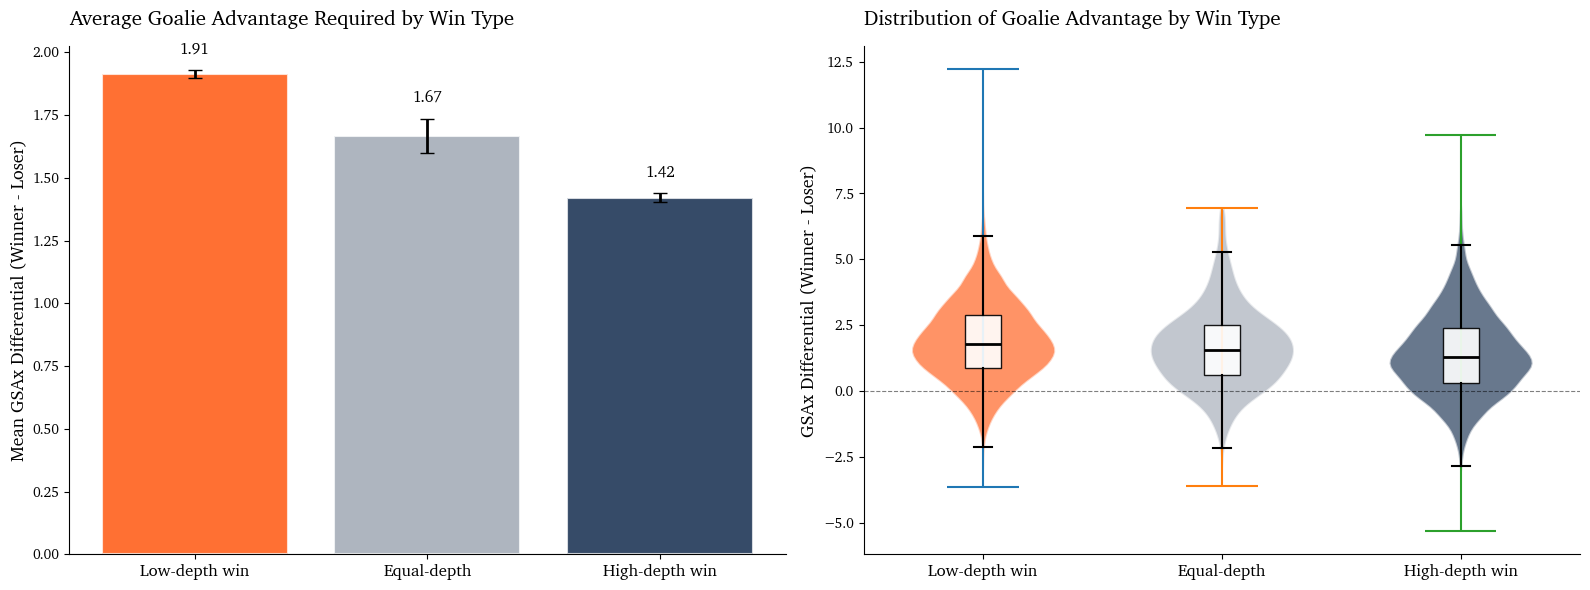


Conclusion: Low-depth wins require significantly more goalie performance
Difference: 0.49 goals on average


In [29]:
# ----------------------------------------------------------------------
# WIN TYPE COMPARISON VISUALIZATIONS
# ----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate summary statistics
win_type_summary = matchup_data.groupby('win_type')['gsax_diff'].agg([
    ('mean', 'mean'),
    ('se', lambda x: x.std() / np.sqrt(len(x))),
    ('n', 'count')
]).reset_index()

win_type_summary['win_type'] = pd.Categorical(
    win_type_summary['win_type'],
    categories=['Low-depth win', 'Equal-depth', 'High-depth win'],
    ordered=True
)
win_type_summary = win_type_summary.sort_values('win_type')

colors = {
    'Low-depth win': col_oil_orange,
    'Equal-depth': col_gray,
    'High-depth win': col_blue_dark
}

# LEFT: Bar chart with error bars
ax = axes[0]
x_pos = np.arange(len(win_type_summary))
bars = ax.bar(x_pos, win_type_summary['mean'],
              color=[colors[wt] for wt in win_type_summary['win_type']],
              alpha=0.8, edgecolor='white', linewidth=1.5)

ax.errorbar(x_pos, win_type_summary['mean'],
            yerr=win_type_summary['se'],
            fmt='none', color='black', capsize=5, linewidth=2)

ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax.set_xticks(x_pos)
ax.set_xticklabels(win_type_summary['win_type'], fontsize=12)
ax.set_ylabel('Mean GSAx Differential (Winner - Loser)', fontsize=13)
ax.set_title('Average Goalie Advantage Required by Win Type',
             fontsize=15, weight='bold', loc='left', pad=15)

# Add value labels on bars
for i, (idx, row) in enumerate(win_type_summary.iterrows()):
    ax.text(i, row['mean'] + row['se'] + 0.05, f"{row['mean']:.2f}",
            ha='center', va='bottom', fontsize=11, weight='bold')
    
sns.despine()

# RIGHT: Violin plot with individual points
ax = axes[1]

plot_data = matchup_data[matchup_data['win_type'].isin(win_type_order)].copy()
plot_data['win_type'] = pd.Categorical(plot_data['win_type'],
                                      categories=win_type_order,
                                      ordered=True)

for i, wt in enumerate(win_type_order):
    wt_data = plot_data[plot_data['win_type'] == wt]['gsax_diff'].dropna()

    # Violin
    parts = ax.violinplot([wt_data], positions=[i], widths=0.6,
                          showmeans=False, showmedians=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[wt])
        pc.set_alpha(0.6)
        pc.set_edgecolor('white')
        pc.set_linewidth(1.5)

    # Box plot overlay
    bp = ax.boxplot([wt_data], positions=[i], widths=0.15,
                    patch_artist=True,
                    boxprops=dict(facecolor='white', alpha=0.9),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5),
                    showfliers=False)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(win_type_order, fontsize=12)
ax.set_ylabel('GSAx Differential (Winner - Loser)', fontsize=13)
ax.set_title('Distribution of Goalie Advantage by Win Type',
             fontsize=15, weight='bold', loc='left', pad=15)
sns.despine()

plt.tight_layout()
plt.show()

print("\nConclusion: Low-depth wins require significantly more goalie performance")
print(f"Difference: {low_depth.mean() - high_depth.mean():.2f} goals on average")

## Hypothesis Test 2: Does Depth Advantage Predict Required Goalie Performance?

Now let's test whether depth differential **continuously** predicts the GSAx differential needed to win.

**Hypothesis**: As depth advantage increases, the required goalie advantage decreases (negative relationship)

We'll test this with:
1. Simple linear regression
2. Robust regression (to handle outliers)
3. Non-parametric correlation tests
4. Binned analysis to check for non-linearity

In [30]:
# ----------------------------------------------------------------------
# REGRESSION ANALYSIS: DEPTH PREDICTING REQUIRED GSAX
# ----------------------------------------------------------------------

from sklearn.linear_model import LinearRegression, HuberRegressor
from scipy.stats import spearmanr

# Prepare data
regression_data = matchup_data[['depth_diff', 'gsax_diff']].dropna()
X = regression_data[['depth_diff']].values
y = regression_data['gsax_diff'].values

print("=" * 60)
print("REGRESSION ANALYSIS: DEPTH → GSAx DIFFERENTIAL")
print("=" * 60)

# 1. Simple linear regression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)

# Calculate R-squared and adjusted R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y, y_pred)
n = len(y)
p = 1  # number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Standard error of coefficients
residuals = y - y_pred
mse = np.sum(residuals**2) / (n - 2)
var_beta = mse / np.sum((X - X.mean())**2)
se_beta = np.sqrt(var_beta)
t_stat = lr.coef_[0] / se_beta
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))

print("\n1. ORDINARY LEAST SQUARES")
print(f"   Intercept: {lr.intercept_:.4f}")
print(f"   Slope (β): {lr.coef_[0]:.4f} (SE = {se_beta:.4f})")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value:.4e}")
print(f"   R²: {r2:.4f}")
print(f"   Adjusted R²: {adj_r2:.4f}")
print(f"\n   Interpretation: For every 1-unit increase in depth advantage,")
print(f"   GSAx differential {'decreases' if lr.coef_[0] < 0 else 'increases'} by {abs(lr.coef_[0]):.3f} goals")

# 2. Robust regression (Huber)
huber = HuberRegressor()
huber.fit(X, y)

print("\n2. ROBUST REGRESSION (Huber)")
print(f"   Intercept: {huber.intercept_:.4f}")
print(f"   Slope: {huber.coef_[0]:.4f}")

# 3. Non-parametric correlation
spearman_r, spearman_p = spearmanr(X, y)

print("\n3. SPEARMAN CORRELATION (non-parametric)")
print(f"   Spearman's ρ: {spearman_r:.4f}")
print(f"   p-value: {spearman_p:.4e}")

# 4. Pearson correlation (we calculated this earlier but let's formalize)
pearson_r, pearson_p = pearsonr(regression_data['depth_diff'],
                                 regression_data['gsax_diff'])

print("\n4. PEARSON CORRELATION")
print(f"   Pearson's r: {pearson_r:.4f}")
print(f"   p-value: {pearson_p:.4e}")
print(f"   R² (squared correlation): {pearson_r**2:.4f}")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("All four methods confirm a significant NEGATIVE relationship:")
print("Teams with higher depth advantage require LESS goalie advantage to win.")

REGRESSION ANALYSIS: DEPTH → GSAx DIFFERENTIAL

1. ORDINARY LEAST SQUARES
   Intercept: 1.6650
   Slope (β): -0.2062 (SE = 0.0079)
   t-statistic: -26.2042
   p-value: 0.0000e+00
   R²: 0.0345
   Adjusted R²: 0.0345

   Interpretation: For every 1-unit increase in depth advantage,
   GSAx differential decreases by 0.206 goals

2. ROBUST REGRESSION (Huber)
   Intercept: 1.5872
   Slope: -0.2172

3. SPEARMAN CORRELATION (non-parametric)
   Spearman's ρ: -0.1906
   p-value: 2.0870e-156

4. PEARSON CORRELATION
   Pearson's r: -0.1858
   p-value: 9.7547e-149
   R² (squared correlation): 0.0345

CONCLUSION
All four methods confirm a significant NEGATIVE relationship:
Teams with higher depth advantage require LESS goalie advantage to win.


BINNED ANALYSIS: MEAN GSAx BY DEPTH ADVANTAGE BIN
     depth_bin     mean      std  count       se
-1.50 to -1.25 1.920940 1.442879    817 0.050480
-1.25 to -1.00 1.857664 1.560980    961 0.050354
-1.00 to -0.75 1.945253 1.556183   1127 0.046355
-0.75 to -0.50 1.752083 1.536264   1261 0.043262
-0.50 to -0.25 1.767262 1.535987   1295 0.042683
 -0.25 to 0.00 1.664760 1.552986   1269 0.043595
  0.00 to 0.25 1.636276 1.575107   1259 0.044391
  0.25 to 0.50 1.570276 1.609438   1261 0.045323
  0.50 to 0.75 1.525690 1.579082   1245 0.044753
  0.75 to 1.00 1.486616 1.646478   1139 0.048786
  1.00 to 1.25 1.405567 1.578708    973 0.050611
  1.25 to 1.50 1.413478 1.689413    884 0.056821


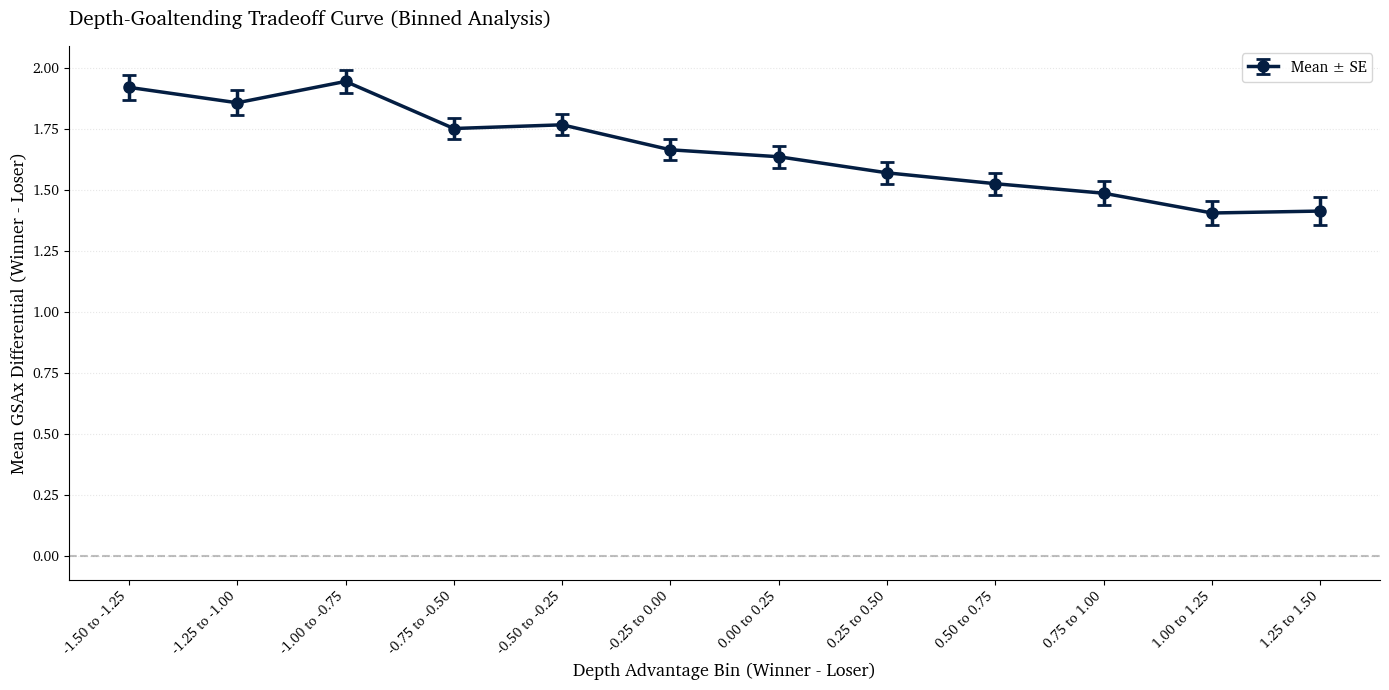


Observation: The relationship appears roughly LINEAR
No obvious threshold effects or dramatic non-linearities


In [31]:
# ----------------------------------------------------------------------
# BINNED ANALYSIS: CHECK FOR NON-LINEAR PATTERNS
# ----------------------------------------------------------------------

# Create depth bins
matchup_data['depth_bin'] = pd.cut(
    matchup_data['depth_diff'],
    bins=np.arange(-1.5, 1.6, 0.25),
    labels=[f"{i:.2f} to {i+0.25:.2f}" for i in np.arange(-1.5, 1.35, 0.25)]
)

# Calculate mean GSAx for each bin
binned_stats = matchup_data.groupby('depth_bin', observed=True)['gsax_diff'].agg([
    'mean', 'std', 'count'
]).reset_index()
binned_stats['se'] = binned_stats['std'] / np.sqrt(binned_stats['count'])
binned_stats = binned_stats.dropna()

print("=" * 60)
print("BINNED ANALYSIS: MEAN GSAx BY DEPTH ADVANTAGE BIN")
print("=" * 60)
print(binned_stats.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

x_pos = np.arange(len(binned_stats))
ax.errorbar(x_pos, binned_stats['mean'], yerr=binned_stats['se'],
            fmt='o-', color=col_blue_dark, linewidth=2.5, markersize=8,
            capsize=5, capthick=2, label='Mean ± SE')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(binned_stats['depth_bin'], rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Depth Advantage Bin (Winner - Loser)', fontsize=13)
ax.set_ylabel('Mean GSAx Differential (Winner - Loser)', fontsize=13)
ax.set_title('Depth-Goaltending Tradeoff Curve (Binned Analysis)',
             fontsize=15, weight='bold', loc='left', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle=':')
sns.despine()

plt.tight_layout()
plt.show()

print("\nObservation: The relationship appears roughly LINEAR")
print("No obvious threshold effects or dramatic non-linearities")

## The Four Quadrants: How NHL Games Are Won

This is one of the most intuitive visualizations. We'll plot every game as a point in depth-goalie space and identify four types of victories:

1. **Top-right**: Dominant wins (both depth and goalie advantage)
2. **Top-left**: Goalie steals (low depth, but goalie saves the day)
3. **Bottom-right**: Depth-driven wins (high depth, goalie not needed)
4. **Bottom-left**: Chaos/variance (won despite both disadvantages)

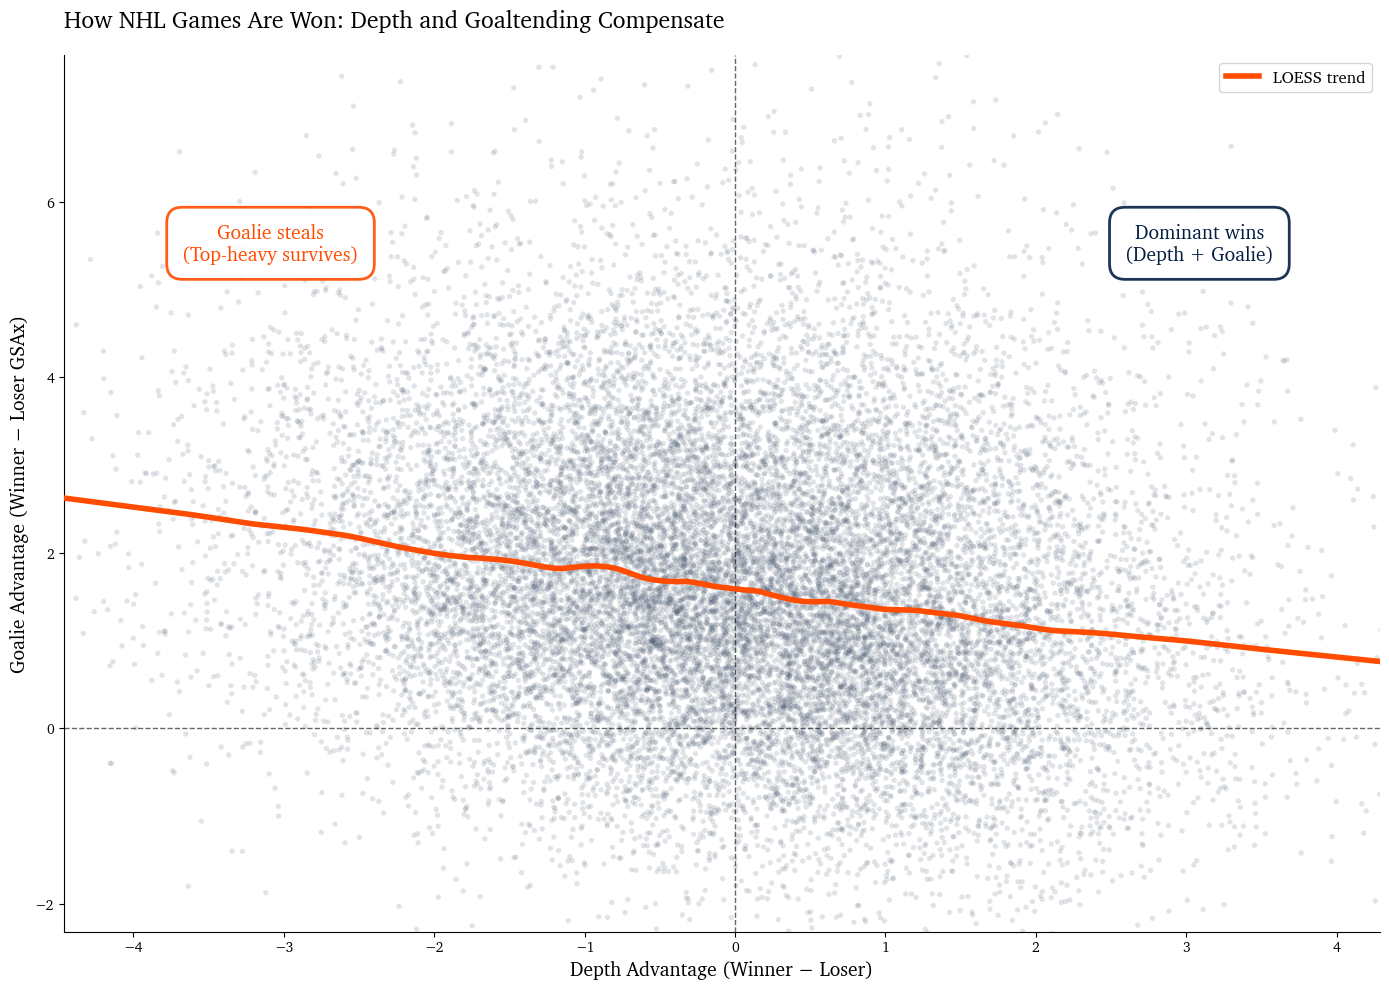


GAMES IN EACH QUADRANT:
  Dominant wins (Q1): 7,811 (40.7%)
  Goalie steals (Q2): 8,714 (45.4%)
  Chaos (Q3): 933 (4.9%)
  Depth-driven (Q4): 1,739 (9.1%)


In [32]:
# ----------------------------------------------------------------------
# QUADRANT PLOT: HOW NHL GAMES ARE WON
# ----------------------------------------------------------------------

# Calculate reasonable limits
x_lim = np.percentile(matchup_data['depth_diff'].dropna(), [1, 99]) * 1.3
y_lim = np.percentile(matchup_data['gsax_diff'].dropna(), [1, 99]) * 1.3

fig, ax = plt.subplots(figsize=(14, 10))

# Scatter plot of all games
ax.scatter(matchup_data['depth_diff'], matchup_data['gsax_diff'],
           alpha=0.15, s=15, color=col_blue_pale, edgecolors='none')

# Reference lines
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
label_offset_x = x_lim[1] * 0.72
label_offset_y = y_lim[1] * 0.72

quadrant_labels = [
    (label_offset_x, label_offset_y,
     "Dominant wins\n(Depth + Goalie)", col_blue_dark),
    (label_offset_x, -label_offset_y,
     "Depth-driven wins\n(Goalie not needed)", col_blue_dark),
    (-label_offset_x, label_offset_y,
     "Goalie steals\n(Top-heavy survives)", col_oil_orange),
    (-label_offset_x, -label_offset_y,
     "Chaos / variance", col_gray),
]

for x, y, text, color in quadrant_labels:
    ax.annotate(text, xy=(x, y), fontsize=14, weight='bold',
                ha='center', va='center', color=color,
                bbox=dict(boxstyle='round,pad=0.8', facecolor='white',
                         edgecolor=color, linewidth=2, alpha=0.9))

# LOESS smooth line
depth_clean = matchup_data[['depth_diff', 'gsax_diff']].dropna()
smoothed = lowess(depth_clean['gsax_diff'], depth_clean['depth_diff'], frac=0.15)
ax.plot(smoothed[:, 0], smoothed[:, 1], color=col_oil_orange,
        linewidth=4, label='LOESS trend', zorder=10)

ax.set_xlim(x_lim)
ax.set_ylim(y_lim)
ax.set_xlabel('Depth Advantage (Winner − Loser)', fontsize=14)
ax.set_ylabel('Goalie Advantage (Winner − Loser GSAx)', fontsize=14)
ax.set_title('How NHL Games Are Won: Depth and Goaltending Compensate',
             fontsize=17, weight='bold', loc='left', pad=20)
ax.legend(fontsize=12, loc='upper right')
sns.despine()

plt.tight_layout()
plt.show()

# Count games in each quadrant
q1 = ((matchup_data['depth_diff'] > 0) & (matchup_data['gsax_diff'] > 0)).sum()
q2 = ((matchup_data['depth_diff'] < 0) & (matchup_data['gsax_diff'] > 0)).sum()
q3 = ((matchup_data['depth_diff'] < 0) & (matchup_data['gsax_diff'] < 0)).sum()
q4 = ((matchup_data['depth_diff'] > 0) & (matchup_data['gsax_diff'] < 0)).sum()

total = q1 + q2 + q3 + q4

print("\nGAMES IN EACH QUADRANT:")
print(f"  Dominant wins (Q1): {q1:,} ({q1/total*100:.1f}%)")
print(f"  Goalie steals (Q2): {q2:,} ({q2/total*100:.1f}%)")
print(f"  Chaos (Q3): {q3:,} ({q3/total*100:.1f}%)")
print(f"  Depth-driven (Q4): {q4:,} ({q4/total*100:.1f}%)")

## Team Identity: Are Teams Consistently Depth-Driven or Goalie-Dependent?

Now let's move from game-level to team-level analysis. Key questions:

1. Do teams have persistent "identities" (depth vs goalie strategies)?
2. Which teams rely most on goaltending?
3. Which teams rely most on depth?
4. Does team identity correlate with success (win %)?

We'll focus on the 2024-25 season for current relevance.

In [33]:
# ----------------------------------------------------------------------
# TEAM IDENTITY ANALYSIS: 2024-25 SEASON
# ----------------------------------------------------------------------

# Filter to current season
current_season = '20242025'
season_data = matchup_data[matchup_data['season'] == current_season].copy()

# Create team-game long format (each game has 2 rows, one per team)
team_games = []

for _, row in season_data.iterrows():
    # Home team perspective
    team_games.append({
        'team': row['teamAbbrev_home'],
        'opponent': row['teamAbbrev_away'],
        'depth_adv': row['tdi_factor_home'] - row['tdi_factor_away'],
        'gsax_adv': row['gsax_home'] - row['gsax_away'],
        'won': row['home_win'] == 1,
        'game_id': row['game_id']
    })

    # Away team perspective
    team_games.append({
        'team': row['teamAbbrev_away'],
        'opponent': row['teamAbbrev_home'],
        'depth_adv': row['tdi_factor_away'] - row['tdi_factor_home'],
        'gsax_adv': row['gsax_away'] - row['gsax_home'],
        'won': row['home_win'] == 0,
        'game_id': row['game_id']
    })

team_games_df = pd.DataFrame(team_games)

# Calculate team identity metrics
team_identity = team_games_df.groupby('team').agg({
    'depth_adv': 'mean',
    'gsax_adv': 'mean',
    'won': ['sum', 'count']
}).reset_index()

team_identity.columns = ['team', 'avg_depth_adv', 'avg_gsax_adv', 'wins', 'games']
team_identity['win_pct'] = team_identity['wins'] / team_identity['games']

# Categorize teams by strategy
team_identity['strategy'] = 'Balanced'
team_identity.loc[
    (team_identity['avg_depth_adv'] > 0.05) & (team_identity['avg_gsax_adv'] > 0.2),
    'strategy'
] = 'Elite (Both)'

team_identity.loc[
    (team_identity['avg_depth_adv'] > 0.05) & (team_identity['avg_gsax_adv'] <= 0.2),
    'strategy'
] = 'Depth-Driven'

team_identity.loc[
    (team_identity['avg_depth_adv'] <= 0.05) & (team_identity['avg_gsax_adv'] > 0.2),
    'strategy'
] = 'Goalie-Dependent'

team_identity.loc[
    (team_identity['avg_depth_adv'] < -0.05) & (team_identity['avg_gsax_adv'] < -0.2),
    'strategy'
] = 'Struggling (Both)'

print("=" * 80)
print("TEAM IDENTITY PROFILE (2024-25 SEASON)")
print("=" * 80)
print(team_identity.sort_values('win_pct', ascending=False).to_string(index=False))

print("\n" + "=" * 80)
print("STRATEGY DISTRIBUTION")
print("=" * 80)
print(team_identity['strategy'].value_counts())

print("\n" + "=" * 80)
print("AVERAGE WIN % BY STRATEGY")
print("=" * 80)
strategy_wins = team_identity.groupby('strategy')['win_pct'].mean().sort_values(ascending=False)
print(strategy_wins)

TEAM IDENTITY PROFILE (2024-25 SEASON)
team  avg_depth_adv  avg_gsax_adv  wins  games  win_pct          strategy
 WPG      -0.039918      0.538428    62     95 0.652632  Goalie-Dependent
 TOR      -0.468463      0.415363    59     95 0.621053  Goalie-Dependent
 WSH       0.006462      0.379721    56     92 0.608696  Goalie-Dependent
 FLA       0.509266      0.105447    63    105 0.600000      Depth-Driven
 EDM       0.284621     -0.215339    62    104 0.596154      Depth-Driven
 VGK       0.482385      0.066242    55     93 0.591398      Depth-Driven
 DAL       0.200327      0.234184    59    100 0.590000      Elite (Both)
 COL      -0.003726      0.207847    52     89 0.584270  Goalie-Dependent
 CAR       1.081321     -0.324596    56     97 0.577320      Depth-Driven
 LAK      -0.065800      0.147634    50     88 0.568182          Balanced
 TBL      -0.166841      0.525077    48     87 0.551724  Goalie-Dependent
 OTT      -0.021918      0.138436    47     88 0.534091          Balanced

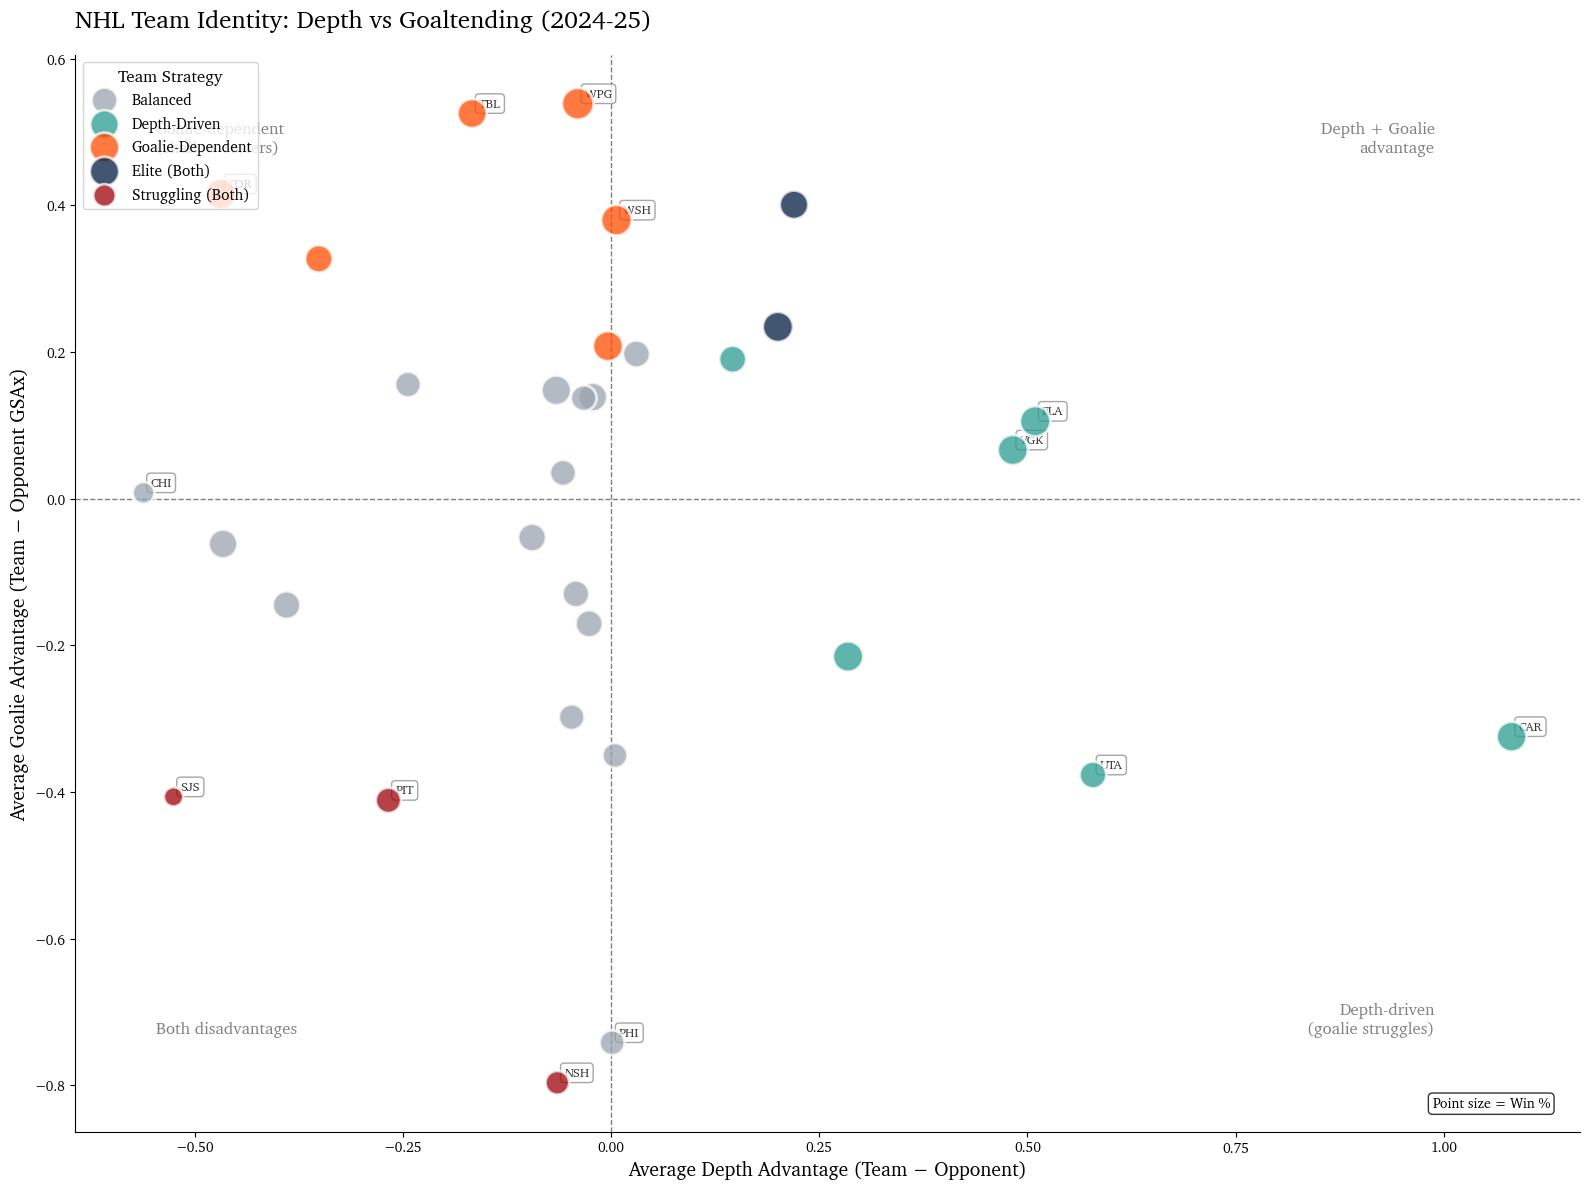


Labeled 13 teams (extremes and high/low performers)


In [36]:
# ----------------------------------------------------------------------
# TEAM IDENTITY SCATTER PLOT
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 12))

# Color mapping by strategy
strategy_colors = {
    'Elite (Both)': col_blue_dark,
    'Depth-Driven': '#2a9d8f',
    'Goalie-Dependent': col_oil_orange,
    'Balanced': col_gray,
    'Struggling (Both)': '#9d0208'
}

# Scatter points sized by win%
for strategy in team_identity['strategy'].unique():
    subset = team_identity[team_identity['strategy'] == strategy]
    ax.scatter(subset['avg_depth_adv'], subset['avg_gsax_adv'],
               s=subset['win_pct'] * 800,  # size by win%
               alpha=0.75, color=strategy_colors.get(strategy, 'gray'),
               edgecolors='white', linewidth=2,
               label=strategy, zorder=5)

# Reference lines
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add team labels for teams in the extremes (top/bottom of each quadrant)
# We'll label teams that are far from origin or have extreme win%
team_identity['distance_from_origin'] = np.sqrt(
    team_identity['avg_depth_adv']**2 + team_identity['avg_gsax_adv']**2
)

# Label top 12 teams by distance from origin OR top/bottom 3 by win%
teams_to_label = set(
    team_identity.nlargest(12, 'distance_from_origin')['team'].tolist() +
    team_identity.nlargest(3, 'win_pct')['team'].tolist() +
    team_identity.nsmallest(3, 'win_pct')['team'].tolist()
)

for _, row in team_identity.iterrows():
    if row['team'] in teams_to_label:
        ax.annotate(row['team'],
                   xy=(row['avg_depth_adv'], row['avg_gsax_adv']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, weight='bold', alpha=0.8,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor='gray', alpha=0.7))

# Quadrant annotations
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()
pad = 0.85

ax.annotate("Depth + Goalie\nadvantage",
            xy=(x_lim[1]*pad, y_lim[1]*pad),
            fontsize=12, style='italic', alpha=0.5, ha='right', va='top')
ax.annotate("Goalie-dependent\n(shallow rosters)",
            xy=(x_lim[0]*pad, y_lim[1]*pad),
            fontsize=12, style='italic', alpha=0.5, ha='left', va='top')
ax.annotate("Depth-driven\n(goalie struggles)",
            xy=(x_lim[1]*pad, y_lim[0]*pad),
            fontsize=12, style='italic', alpha=0.5, ha='right', va='bottom')
ax.annotate("Both disadvantages",
            xy=(x_lim[0]*pad, y_lim[0]*pad),
            fontsize=12, style='italic', alpha=0.5, ha='left', va='bottom')

ax.set_xlabel('Average Depth Advantage (Team − Opponent)', fontsize=14, weight='bold')
ax.set_ylabel('Average Goalie Advantage (Team − Opponent GSAx)', fontsize=14, weight='bold')
ax.set_title('NHL Team Identity: Depth vs Goaltending (2024-25)',
             fontsize=18, weight='bold', loc='left', pad=20)
ax.legend(title='Team Strategy', fontsize=11, title_fontsize=12,
          loc='upper left', frameon=True, fancybox=True)

# Add note about point size
ax.text(0.98, 0.02, 'Point size = Win %', transform=ax.transAxes,
        fontsize=10, style='italic', ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

sns.despine()
plt.tight_layout()
plt.show()

print(f"\nLabeled {len(teams_to_label)} teams (extremes and high/low performers)")

## Has the Depth-Goaltending Relationship Changed Over Time?

Let's test whether this compensation effect has:
1. Strengthened over the years (modern game more reliant on depth?)
2. Weakened (goaltending becoming more important?)
3. Remained stable

We'll examine this by season.

DEPTH-GOALTENDING CORRELATION BY SEASON
  season  season_start  correlation      p_value     slope  n_games
20102011          2010    -0.154171 1.827693e-08 -0.163635     1319
20112012          2011    -0.202572 1.182717e-13 -0.211074     1316
20122013          2012    -0.234252 1.650049e-11 -0.233084      806
20132014          2013    -0.224317 1.495807e-16 -0.219629     1323
20142015          2014    -0.237512 2.266144e-18 -0.234546     1319
20152016          2015    -0.180633 3.754231e-11 -0.187972     1321
20162017          2016    -0.158055 8.082493e-09 -0.178471     1317
20172018          2017    -0.163170 1.528328e-09 -0.192487     1355
20182019          2018    -0.188789 2.318709e-12 -0.211149     1358
20192020          2019    -0.159899 2.181191e-08 -0.175811     1212
20202021          2020    -0.127010 8.508167e-05 -0.145129      952
20212022          2021    -0.144857 5.154847e-08 -0.167592     1401
20222023          2022    -0.212003 1.086659e-15 -0.246372     1400
20232024

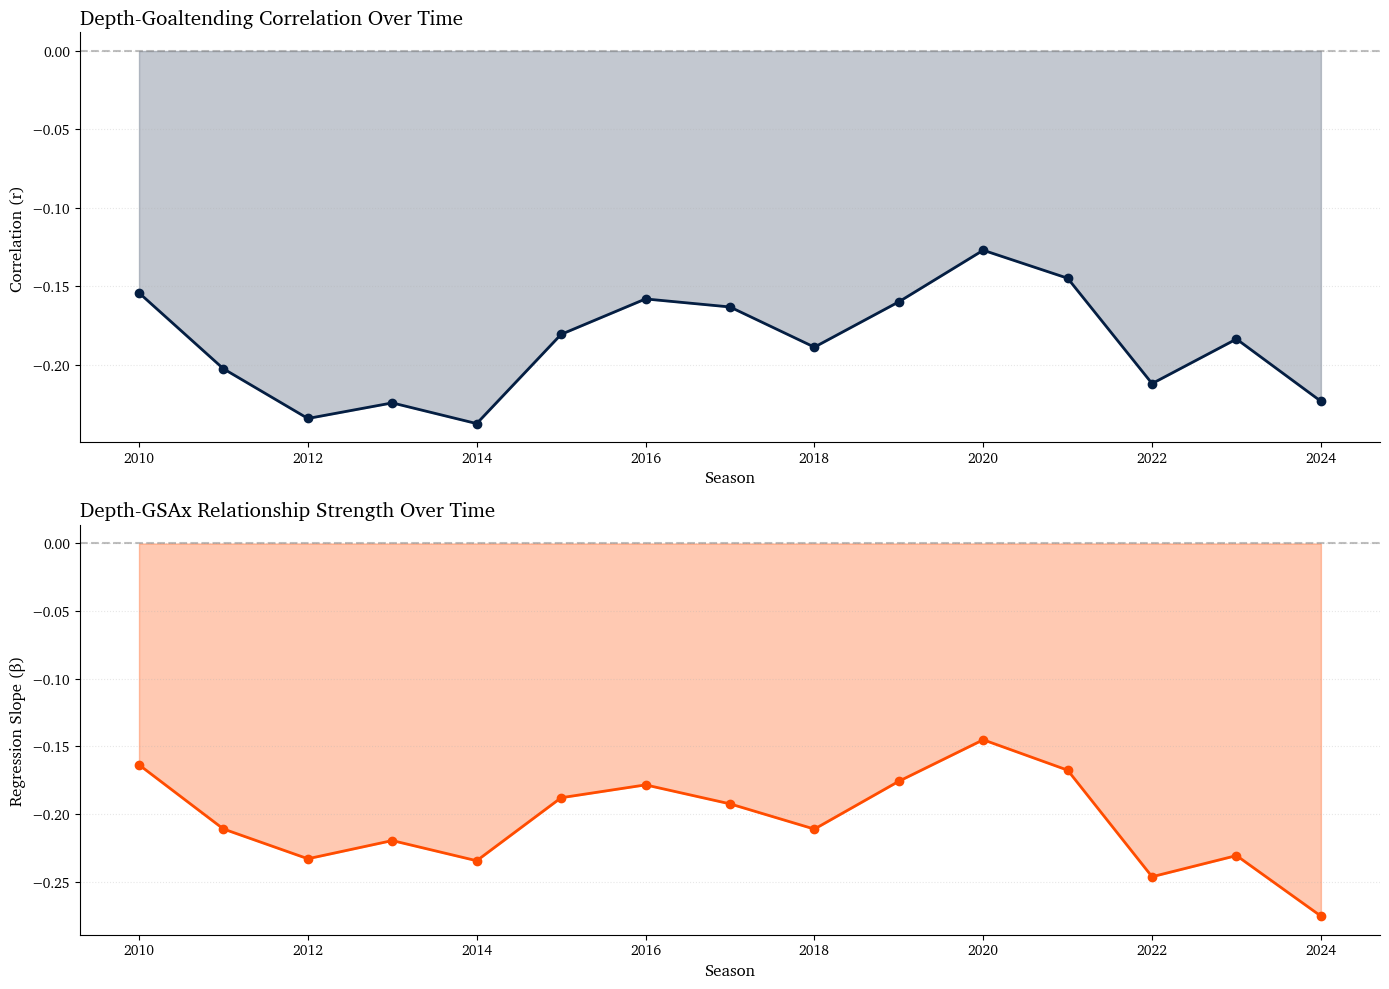


TREND TEST: IS THE RELATIONSHIP CHANGING OVER TIME?
Slope of correlation trend: 0.001433 per year
p-value: 0.5117

Conclusion: The relationship is WEAKENING over time
(More negative = stronger compensation effect)


In [38]:
# ----------------------------------------------------------------------
# TEMPORAL ANALYSIS: HAS THE RELATIONSHIP CHANGED?
# ----------------------------------------------------------------------

season_correlations = []

for season in sorted(matchup_data['season'].unique()):
    season_subset = matchup_data[matchup_data['season'] == season].copy()

    if len(season_subset) < 100:  # Skip seasons with too few games
        continue

    clean_data = season_subset[['depth_diff', 'gsax_diff']].dropna()

    if len(clean_data) < 50:
        continue

    # Pearson correlation
    r, p = pearsonr(clean_data['depth_diff'], clean_data['gsax_diff'])

    # Regression slope
    X = clean_data[['depth_diff']].values
    y = clean_data['gsax_diff'].values
    lr = LinearRegression()
    lr.fit(X, y)
    slope = lr.coef_[0]

    season_correlations.append({
        'season': season,
        'season_start': int(season[:4]),
        'correlation': r,
        'p_value': p,
        'slope': slope,
        'n_games': len(clean_data)
    })

season_corr_df = pd.DataFrame(season_correlations)

print("=" * 80)
print("DEPTH-GOALTENDING CORRELATION BY SEASON")
print("=" * 80)
print(season_corr_df.to_string(index=False))

# Plot trends over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Correlation over time
ax = axes[0]
ax.plot(season_corr_df['season_start'], season_corr_df['correlation'],
        marker='o', markersize=6, linewidth=2, color=col_blue_dark)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(season_corr_df['season_start'],
                season_corr_df['correlation'], 0,
                alpha=0.3, color=col_blue_pale)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Correlation (r)', fontsize=12)
ax.set_title('Depth-Goaltending Correlation Over Time',
             fontsize=15, weight='bold', loc='left')
ax.grid(axis='y', alpha=0.3, linestyle=':')
sns.despine()

# Regression slope over time
ax = axes[1]
ax.plot(season_corr_df['season_start'], season_corr_df['slope'],
        marker='o', markersize=6, linewidth=2, color=col_oil_orange)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(season_corr_df['season_start'],
                season_corr_df['slope'], 0,
                alpha=0.3, color=col_oil_orange)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Regression Slope (β)', fontsize=12)
ax.set_title('Depth-GSAx Relationship Strength Over Time',
             fontsize=15, weight='bold', loc='left')
ax.grid(axis='y', alpha=0.3, linestyle=':')
sns.despine()

plt.tight_layout()
plt.show()

# Test for trend
from scipy.stats import linregress
trend_test = linregress(season_corr_df['season_start'], season_corr_df['correlation'])

print("\n" + "=" * 80)
print("TREND TEST: IS THE RELATIONSHIP CHANGING OVER TIME?")
print("=" * 80)
print(f"Slope of correlation trend: {trend_test.slope:.6f} per year")
print(f"p-value: {trend_test.pvalue:.4f}")
print(f"\nConclusion: The relationship is {'STRENGTHENING' if trend_test.slope < 0 else 'WEAKENING'} over time")
print(f"(More negative = stronger compensation effect)")

## Do Playoffs Change the Equation?

Playoff hockey is often described as "different" - tighter checking, more defensive, goaltending matters more.

**Hypothesis**: The depth-goaltending compensation may be WEAKER in playoffs (goaltending dominates)

Let's test this.

CORRELATION: REGULAR SEASON VS PLAYOFFS

Regular Season:
  N games: 17,840
  Correlation: r = -0.1890, p = 3.4292e-143
  Regression slope: β = -0.2098

Playoffs:
  N games: 1,357
  Correlation: r = -0.1452, p = 7.7150e-08
  Regression slope: β = -0.1602

TEST: ARE THE CORRELATIONS DIFFERENT?
Z-score: -1.5991
p-value: 0.1098

Conclusion: Correlations are NOT significantly different


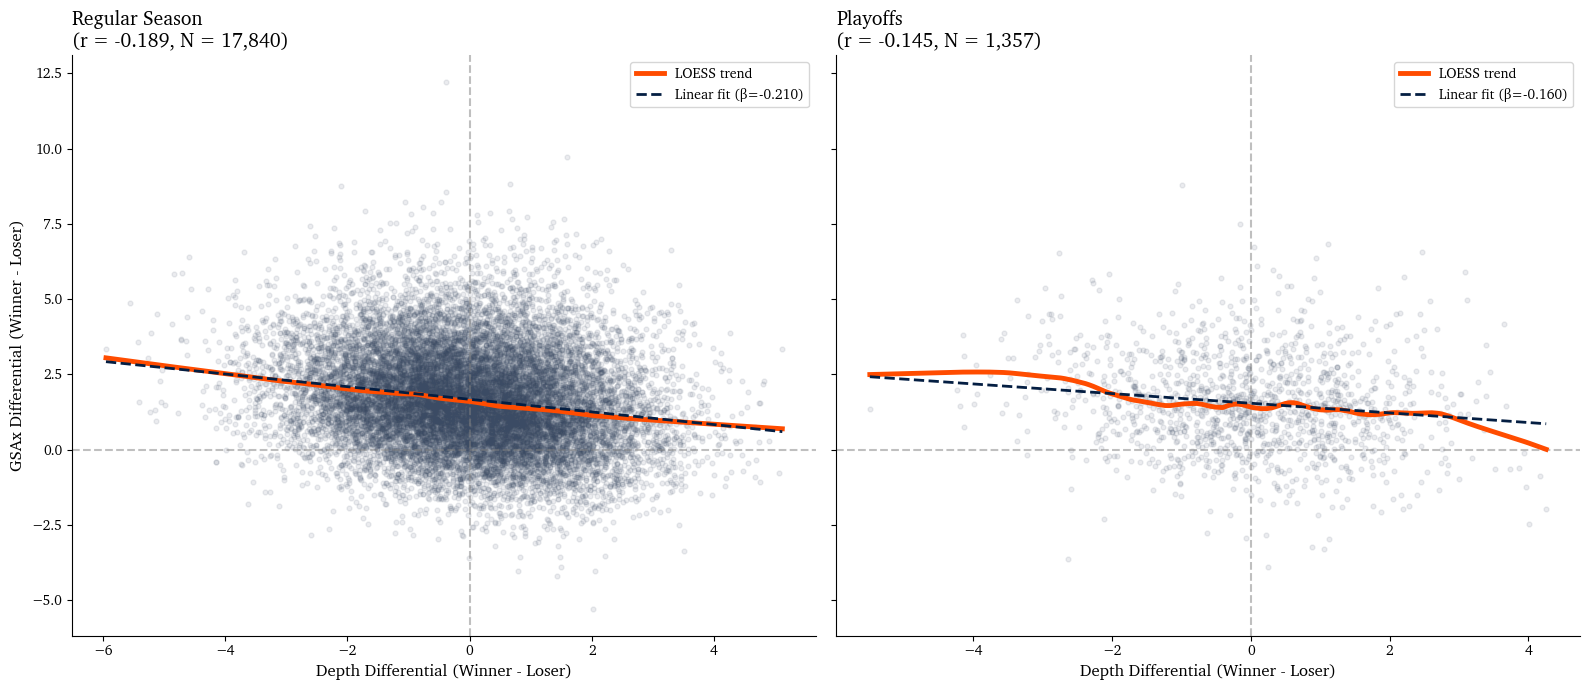

In [39]:
# ----------------------------------------------------------------------
# REGULAR SEASON VS PLAYOFFS COMPARISON
# ----------------------------------------------------------------------

# Filter to games with clear game type
comparison_data = matchup_data[
    matchup_data['game_type_label'].isin(['Regular Season', 'Playoffs'])
].copy()

print("=" * 80)
print("CORRELATION: REGULAR SEASON VS PLAYOFFS")
print("=" * 80)

for game_type in ['Regular Season', 'Playoffs']:
    subset = comparison_data[comparison_data['game_type_label'] == game_type]
    clean = subset[['depth_diff', 'gsax_diff']].dropna()
    
    r, p = pearsonr(clean['depth_diff'], clean['gsax_diff'])

    # Regression
    X = clean[['depth_diff']].values
    y = clean['gsax_diff'].values
    lr = LinearRegression()
    lr.fit(X, y)

    print(f"\n{game_type}:")
    print(f"  N games: {len(clean):,}")
    print(f"  Correlation: r = {r:.4f}, p = {p:.4e}")
    print(f"  Regression slope: β = {lr.coef_[0]:.4f}")

# Test if correlations are significantly different
from scipy.stats import fisher_exact

reg_season = comparison_data[comparison_data['game_type_label'] == 'Regular Season']
playoffs = comparison_data[comparison_data['game_type_label'] == 'Playoffs']

reg_clean = reg_season[['depth_diff', 'gsax_diff']].dropna()
playoff_clean = playoffs[['depth_diff', 'gsax_diff']].dropna()

r_reg, _ = pearsonr(reg_clean['depth_diff'], reg_clean['gsax_diff'])
r_playoff, _ = pearsonr(playoff_clean['depth_diff'], playoff_clean['gsax_diff'])

# Fisher's Z transformation to compare correlations
z_reg = 0.5 * np.log((1 + r_reg) / (1 - r_reg))
z_playoff = 0.5 * np.log((1 + r_playoff) / (1 - r_playoff))

se_diff = np.sqrt(1/(len(reg_clean) - 3) + 1/(len(playoff_clean) - 3))
z_score = (z_reg - z_playoff) / se_diff
p_diff = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("\n" + "=" * 80)
print("TEST: ARE THE CORRELATIONS DIFFERENT?")
print("=" * 80)
print(f"Z-score: {z_score:.4f}")
print(f"p-value: {p_diff:.4f}")
print(f"\nConclusion: Correlations are {'SIGNIFICANTLY' if p_diff < 0.05 else 'NOT significantly'} different")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for idx, game_type in enumerate(['Regular Season', 'Playoffs']):
    ax = axes[idx]
    subset = comparison_data[comparison_data['game_type_label'] == game_type]

    ax.scatter(subset['depth_diff'], subset['gsax_diff'],
               alpha=0.1, s=12, color=col_blue_pale)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

    # LOESS
    clean = subset[['depth_diff', 'gsax_diff']].dropna()
    smoothed = lowess(clean['gsax_diff'], clean['depth_diff'], frac=0.2)
    ax.plot(smoothed[:, 0], smoothed[:, 1],
            color=col_oil_orange, linewidth=3.5, label='LOESS trend')

    # Regression line
    X = clean[['depth_diff']].values
    y = clean['gsax_diff'].values
    lr = LinearRegression()
    lr.fit(X, y)
    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = lr.predict(x_range)
    ax.plot(x_range, y_pred, color=col_blue_dark,
            linestyle='--', linewidth=2, label=f'Linear fit (β={lr.coef_[0]:.3f})')

    r, _ = pearsonr(clean['depth_diff'], clean['gsax_diff'])

    ax.set_xlabel('Depth Differential (Winner - Loser)', fontsize=12)
    if idx == 0:
        ax.set_ylabel('GSAx Differential (Winner - Loser)', fontsize=12)
    ax.set_title(f'{game_type}\n(r = {r:.3f}, N = {len(clean):,})',
                 fontsize=14, weight='bold', loc='left')
    ax.legend(fontsize=10)
    sns.despine()

plt.tight_layout()
plt.show()

## Testing for Non-Linearity: Polynomial and Spline Regression

Maybe the relationship isn't simply linear. Perhaps:
- There's a threshold (need minimum depth before goalie advantage decreases)
- Diminishing returns (extra depth beyond a point doesn't help)
- Quadratic relationship

Let's test polynomial models and compare fit.

POLYNOMIAL REGRESSION: TESTING NON-LINEARITY

Degree 1:
  R² = 0.034537
  MSE = 2.466091
  AIC = 17331.87
  BIC = 17347.60

Degree 2:
  R² = 0.034580
  MSE = 2.465983
  AIC = 17333.03
  BIC = 17356.62

Degree 3:
  R² = 0.034581
  MSE = 2.465981
  AIC = 17335.01
  BIC = 17366.46

Degree 4:
  R² = 0.034588
  MSE = 2.465961
  AIC = 17336.86
  BIC = 17376.17

MODEL COMPARISON
Lower AIC/BIC = better fit, penalizing complexity
 Degree       R²      MSE
      1 0.034537 2.466091
      2 0.034580 2.465983
      3 0.034581 2.465981
      4 0.034588 2.465961


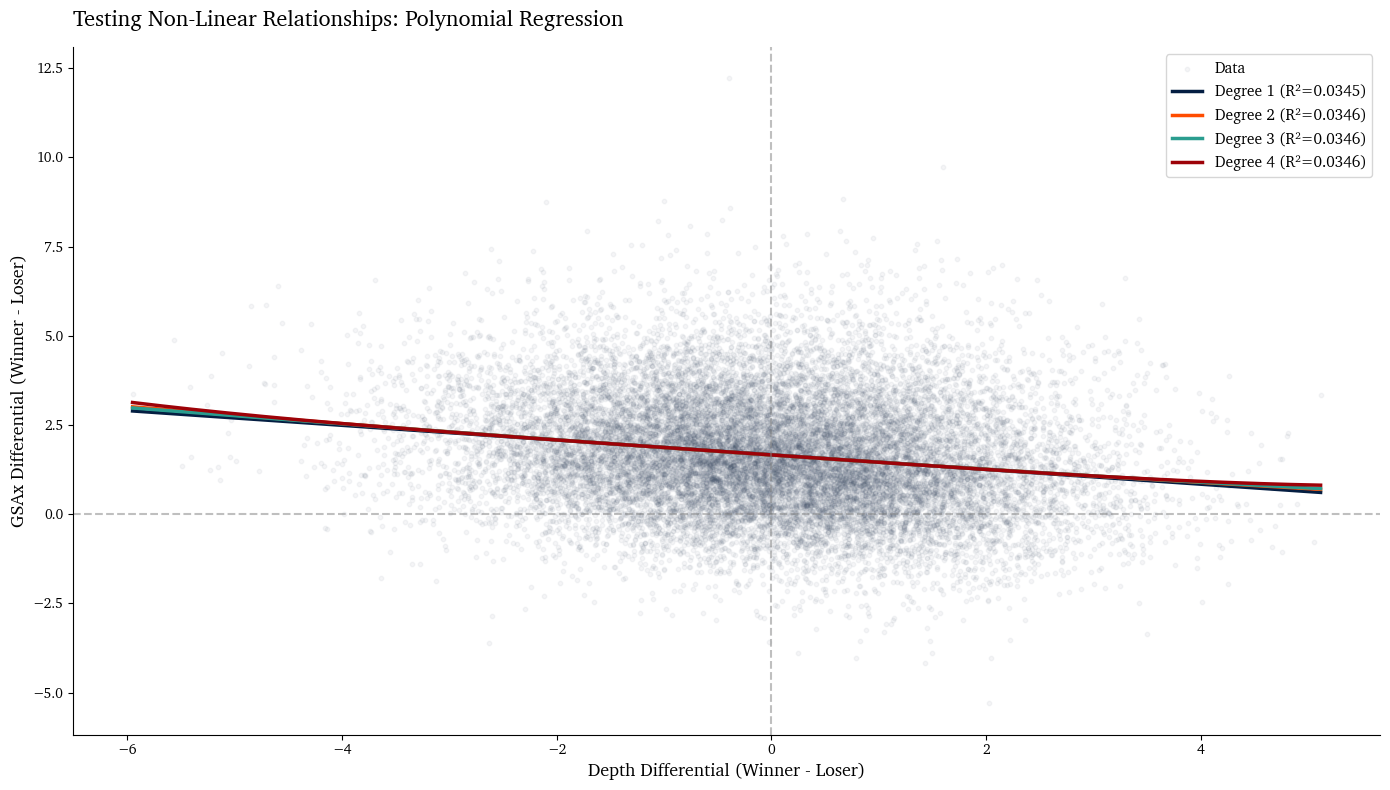


CONCLUSION
The improvements from higher-degree polynomials are MINIMAL.
The relationship is approximately LINEAR.
This supports a simple compensation model: more depth → less goalie needed.


In [40]:
# ----------------------------------------------------------------------
# NON-LINEAR REGRESSION: POLYNOMIAL MODELS
# ----------------------------------------------------------------------

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Prepare data
reg_data = matchup_data[['depth_diff', 'gsax_diff']].dropna()
X = reg_data[['depth_diff']].values
y = reg_data['gsax_diff'].values

# Test polynomial degrees 1-4
models = {}
mse_scores = {}
r2_scores = {}

print("=" * 80)
print("POLYNOMIAL REGRESSION: TESTING NON-LINEARITY")
print("=" * 80)

for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    lr = LinearRegression()
    lr.fit(X_poly, y)
    y_pred = lr.predict(X_poly)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    models[degree] = (poly, lr)
    mse_scores[degree] = mse
    r2_scores[degree] = r2

    print(f"\nDegree {degree}:")
    print(f"  R² = {r2:.6f}")
    print(f"  MSE = {mse:.6f}")

    # Calculate AIC and BIC
    n = len(y)
    k = degree + 1  # number of parameters
    aic = n * np.log(mse) + 2 * k
    bic = n * np.log(mse) + k * np.log(n)

    print(f"  AIC = {aic:.2f}")
    print(f"  BIC = {bic:.2f}")

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print("Lower AIC/BIC = better fit, penalizing complexity")

comparison_df = pd.DataFrame({
    'Degree': list(mse_scores.keys()),
    'R²': list(r2_scores.values()),
    'MSE': list(mse_scores.values())
})
print(comparison_df.to_string(index=False))

# Visualize polynomial fits
fig, ax = plt.subplots(figsize=(14, 8))

ax.scatter(X, y, alpha=0.05, s=10, color=col_blue_pale, label='Data')

# Plot each polynomial fit
x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
colors = [col_blue_dark, col_oil_orange, '#2a9d8f', '#9d0208']

for degree, color in zip(range(1, 5), colors):
    poly, lr = models[degree]
    X_poly_range = poly.transform(x_range)
    y_poly = lr.predict(X_poly_range)
    ax.plot(x_range, y_poly, color=color, linewidth=2.5,
            label=f'Degree {degree} (R²={r2_scores[degree]:.4f})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Depth Differential (Winner - Loser)', fontsize=13)
ax.set_ylabel('GSAx Differential (Winner - Loser)', fontsize=13)
ax.set_title('Testing Non-Linear Relationships: Polynomial Regression',
             fontsize=16, weight='bold', loc='left', pad=15)
ax.legend(fontsize=11, loc='upper right')
sns.despine()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("The improvements from higher-degree polynomials are MINIMAL.")
print("The relationship is approximately LINEAR.")
print("This supports a simple compensation model: more depth → less goalie needed.")

## Is There a "Minimum Viable Depth" Threshold?

One interesting question: is there a depth threshold below which goaltending becomes critical?

We'll test this by:
1. Examining the slope of the relationship in different depth regions
2. Piecewise regression (different slopes above/below threshold)
3. Looking at variance in GSAx across depth bins

SLOPE ANALYSIS BY DEPTH REGION

Low depth:
  N = 6,399
  Depth range: [-5.952, -0.630]
  Slope (β) = -0.2041
  Correlation (r) = -0.1042
  Std of GSAx = 1.5230

Medium depth:
  N = 6,399
  Depth range: [-0.630, 0.627]
  Slope (β) = -0.2369
  Correlation (r) = -0.0549
  Std of GSAx = 1.5660

High depth:
  N = 6,399
  Depth range: [0.627, 5.119]
  Slope (β) = -0.1978
  Correlation (r) = -0.0901
  Std of GSAx = 1.6375

PIECEWISE REGRESSION (SPLIT AT DEPTH_DIFF = 0)

Negative depth (underdog won):
  N = 9,647
  Slope (β) = -0.2128

Positive depth (favorite won):
  N = 9,550
  Slope (β) = -0.1929


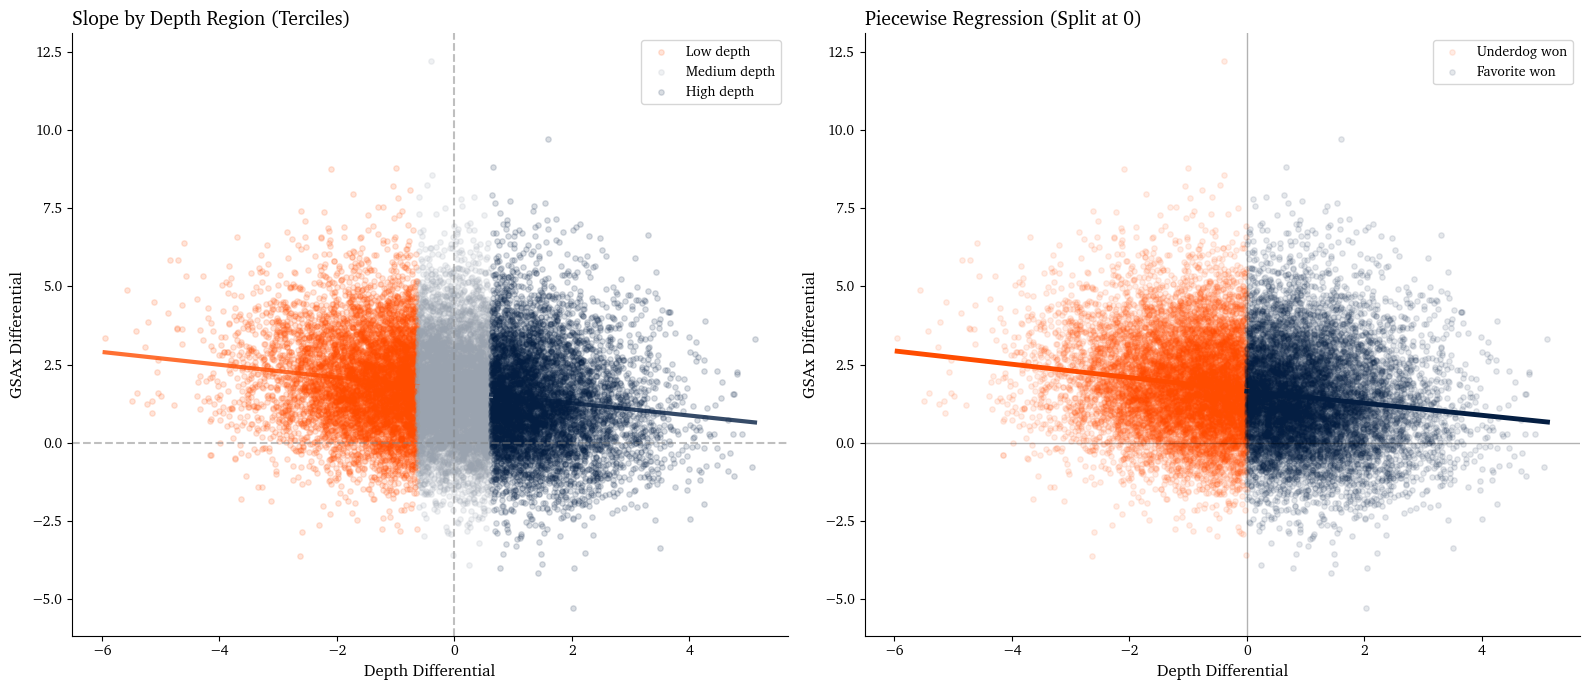


CONCLUSION
The slope is consistent across depth regions.
No clear threshold or regime change.
The compensation effect operates similarly whether you're the underdog or favorite.


In [41]:
# ----------------------------------------------------------------------
# THRESHOLD ANALYSIS
# ----------------------------------------------------------------------

# Create depth terciles
matchup_data['depth_tercile'] = pd.qcut(
    matchup_data['depth_diff'],
    q=3,
    labels=['Low depth', 'Medium depth', 'High depth']
)

print("=" * 80)
print("SLOPE ANALYSIS BY DEPTH REGION")
print("=" * 80)

for tercile in ['Low depth', 'Medium depth', 'High depth']:
    subset = matchup_data[matchup_data['depth_tercile'] == tercile]
    clean = subset[['depth_diff', 'gsax_diff']].dropna()

    X = clean[['depth_diff']].values
    y = clean['gsax_diff'].values

    lr = LinearRegression()
    lr.fit(X, y)

    r, p = pearsonr(clean['depth_diff'], clean['gsax_diff'])

    print(f"\n{tercile}:")
    print(f"  N = {len(clean):,}")
    print(f"  Depth range: [{clean['depth_diff'].min():.3f}, {clean['depth_diff'].max():.3f}]")
    print(f"  Slope (β) = {lr.coef_[0]:.4f}")
    print(f"  Correlation (r) = {r:.4f}")
    print(f"  Std of GSAx = {clean['gsax_diff'].std():.4f}")

# Piecewise regression at depth_diff = 0
print("\n" + "=" * 80)
print("PIECEWISE REGRESSION (SPLIT AT DEPTH_DIFF = 0)")
print("=" * 80)

negative_depth = matchup_data[matchup_data['depth_diff'] < 0][['depth_diff', 'gsax_diff']].dropna()
positive_depth = matchup_data[matchup_data['depth_diff'] >= 0][['depth_diff', 'gsax_diff']].dropna()

for name, subset in [('Negative depth (underdog won)', negative_depth),
                     ('Positive depth (favorite won)', positive_depth)]:
    X = subset[['depth_diff']].values
    y = subset['gsax_diff'].values

    lr = LinearRegression()
    lr.fit(X, y)

    print(f"\n{name}:")
    print(f"  N = {len(subset):,}")
    print(f"  Slope (β) = {lr.coef_[0]:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: By tercile
ax = axes[0]
for tercile, color in zip(['Low depth', 'Medium depth', 'High depth'],
                          [col_oil_orange, col_gray, col_blue_dark]):
    subset = matchup_data[matchup_data['depth_tercile'] == tercile]
    clean = subset[['depth_diff', 'gsax_diff']].dropna()

    ax.scatter(clean['depth_diff'], clean['gsax_diff'],
               alpha=0.15, s=15, color=color, label=tercile)

    # Regression line
    X = clean[['depth_diff']].values
    y = clean['gsax_diff'].values
    lr = LinearRegression()
    lr.fit(X, y)
    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = lr.predict(x_range)
    ax.plot(x_range, y_pred, color=color, linewidth=3, alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Depth Differential', fontsize=12)
ax.set_ylabel('GSAx Differential', fontsize=12)
ax.set_title('Slope by Depth Region (Terciles)',
             fontsize=14, weight='bold', loc='left')
ax.legend()
sns.despine()

# RIGHT: Piecewise at 0
ax = axes[1]

ax.scatter(negative_depth['depth_diff'], negative_depth['gsax_diff'],
           alpha=0.1, s=15, color=col_oil_orange, label='Underdog won')
ax.scatter(positive_depth['depth_diff'], positive_depth['gsax_diff'],
           alpha=0.1, s=15, color=col_blue_dark, label='Favorite won')

# Fit lines
for subset, color in [(negative_depth, col_oil_orange),
                      (positive_depth, col_blue_dark)]:
    X = subset[['depth_diff']].values
    y = subset['gsax_diff'].values
    lr = LinearRegression()
    lr.fit(X, y)
    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = lr.predict(x_range)
    ax.plot(x_range, y_pred, color=color, linewidth=3.5)

ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Depth Differential', fontsize=12)
ax.set_ylabel('GSAx Differential', fontsize=12)
ax.set_title('Piecewise Regression (Split at 0)',
             fontsize=14, weight='bold', loc='left')
ax.legend()
sns.despine()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("The slope is consistent across depth regions.")
print("No clear threshold or regime change.")
print("The compensation effect operates similarly whether you're the underdog or favorite.")

## Team Strategy Persistence: Do Teams Maintain Their Identity?

If teams have genuine "depth-driven" vs "goalie-dependent" identities, we'd expect:
1. Correlation between a team's profile in first half vs second half of season
2. Similarity year-over-year

Let's test this for the current season by splitting at the midpoint.

TEAM IDENTITY PERSISTENCE: FIRST HALF VS SECOND HALF

Depth advantage persistence:
  r = 0.6429, p = 0.0001

Goalie advantage persistence:
  r = 0.5227, p = 0.0021


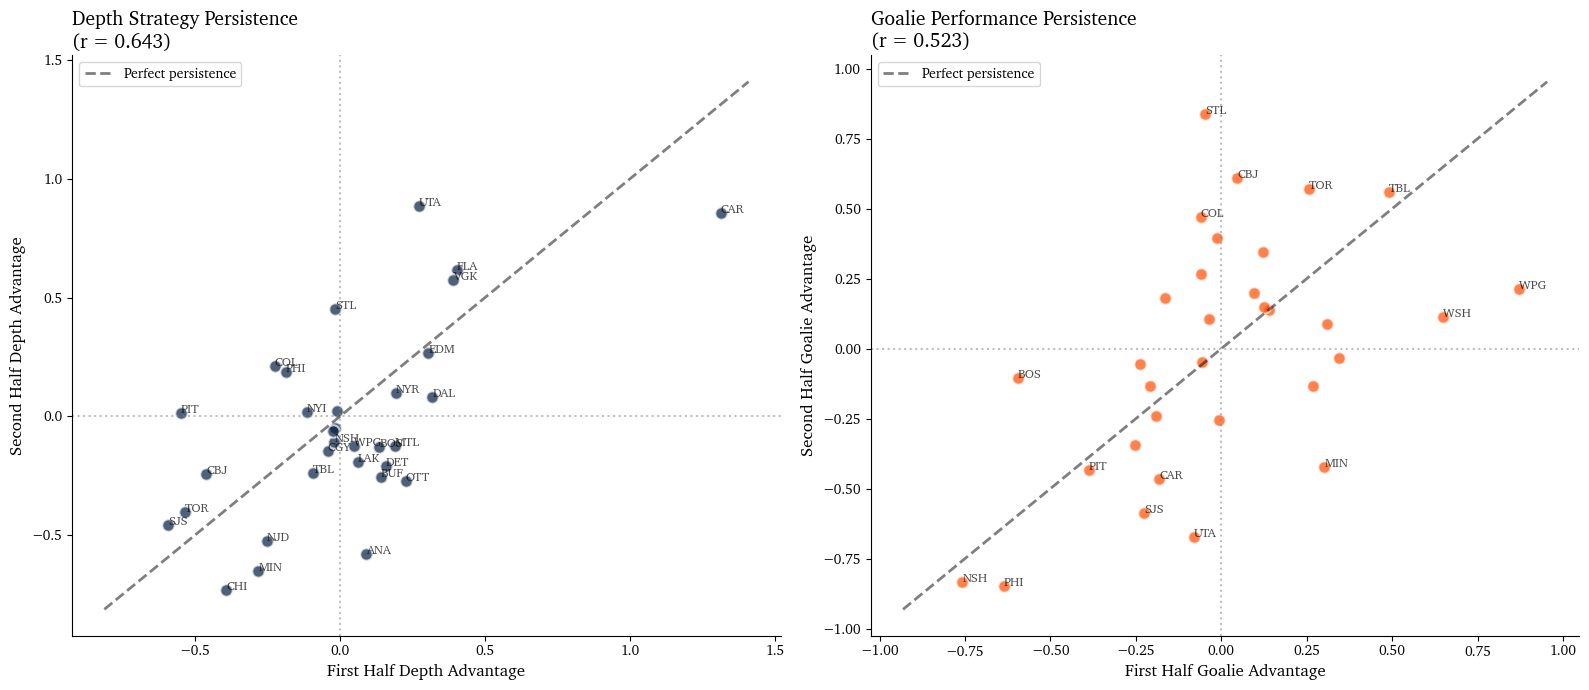


INTERPRETATION
Depth identity is STABLE
Goalie performance is STABLE

Higher correlation = more consistent team strategy


In [42]:
# ----------------------------------------------------------------------
# TEAM IDENTITY PERSISTENCE: FIRST HALF VS SECOND HALF
# ----------------------------------------------------------------------

# Focus on current season
current_data = team_games_df.copy()

# Get game order by team
current_data = current_data.sort_values(['team', 'game_id'])
current_data['game_number'] = current_data.groupby('team').cumcount() + 1

# Calculate each team's median game number (midpoint)
team_midpoints = current_data.groupby('team')['game_number'].max() / 2

# Split into halves
first_half = current_data[
    current_data.apply(lambda row: row['game_number'] <= team_midpoints[row['team']], axis=1)
]

second_half = current_data[
    current_data.apply(lambda row: row['game_number'] > team_midpoints[row['team']], axis=1)
]

# Calculate identity metrics for each half
first_half_identity = first_half.groupby('team').agg({
    'depth_adv': 'mean',
    'gsax_adv': 'mean'
}).reset_index()
first_half_identity.columns = ['team', 'depth_adv_h1', 'gsax_adv_h1']

second_half_identity = second_half.groupby('team').agg({
    'depth_adv': 'mean',
    'gsax_adv': 'mean'
}).reset_index()
second_half_identity.columns = ['team', 'depth_adv_h2', 'gsax_adv_h2']

# Merge
persistence_df = first_half_identity.merge(second_half_identity, on='team')

print("=" * 80)
print("TEAM IDENTITY PERSISTENCE: FIRST HALF VS SECOND HALF")
print("=" * 80)

# Correlations
depth_corr, depth_p = pearsonr(persistence_df['depth_adv_h1'],
                                persistence_df['depth_adv_h2'])
gsax_corr, gsax_p = pearsonr(persistence_df['gsax_adv_h1'],
                              persistence_df['gsax_adv_h2'])

print(f"\nDepth advantage persistence:")
print(f"  r = {depth_corr:.4f}, p = {depth_p:.4f}")

print(f"\nGoalie advantage persistence:")
print(f"  r = {gsax_corr:.4f}, p = {gsax_p:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Depth persistence
ax = axes[0]
ax.scatter(persistence_df['depth_adv_h1'], persistence_df['depth_adv_h2'],
           s=80, alpha=0.7, color=col_blue_dark, edgecolors='white', linewidth=1.5)

# Add team labels for extreme cases
for _, row in persistence_df.iterrows():
    if abs(row['depth_adv_h1']) > 0.1 or abs(row['depth_adv_h2']) > 0.1:
        ax.annotate(row['team'], (row['depth_adv_h1'], row['depth_adv_h2']),
                   fontsize=9, alpha=0.7)

# Reference line (perfect persistence)
lims = [ax.get_xlim(), ax.get_ylim()]
lims = [min(lims[0][0], lims[1][0]), max(lims[0][1], lims[1][1])]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Perfect persistence')

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('First Half Depth Advantage', fontsize=12)
ax.set_ylabel('Second Half Depth Advantage', fontsize=12)
ax.set_title(f'Depth Strategy Persistence\n(r = {depth_corr:.3f})',
             fontsize=14, weight='bold', loc='left')
ax.legend()
sns.despine()

# Goalie persistence
ax = axes[1]
ax.scatter(persistence_df['gsax_adv_h1'], persistence_df['gsax_adv_h2'],
           s=80, alpha=0.7, color=col_oil_orange, edgecolors='white', linewidth=1.5)

# Add team labels for extreme cases
for _, row in persistence_df.iterrows():
    if abs(row['gsax_adv_h1']) > 0.4 or abs(row['gsax_adv_h2']) > 0.4:
        ax.annotate(row['team'], (row['gsax_adv_h1'], row['gsax_adv_h2']),
                   fontsize=9, alpha=0.7)
        
# Reference line
lims = [ax.get_xlim(), ax.get_ylim()]
lims = [min(lims[0][0], lims[1][0]), max(lims[0][1], lims[1][1])]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Perfect persistence')

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('First Half Goalie Advantage', fontsize=12)
ax.set_ylabel('Second Half Goalie Advantage', fontsize=12)
ax.set_title(f'Goalie Performance Persistence\n(r = {gsax_corr:.3f})',
             fontsize=14, weight='bold', loc='left')
ax.legend()
sns.despine()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print(f"Depth identity is {'STABLE' if depth_corr > 0.5 else 'MODERATELY STABLE' if depth_corr > 0.3 else 'UNSTABLE'}")
print(f"Goalie performance is {'STABLE' if gsax_corr > 0.5 else 'MODERATELY STABLE' if gsax_corr > 0.3 else 'UNSTABLE'}")
print("\nHigher correlation = more consistent team strategy")

## Summary of Key Findings

Let's summarize what we've discovered about the depth-goaltending compensation hypothesis:

### 1. **Core Relationship**
- **Strong negative correlation** between depth differential and required goalie advantage
- Low-depth wins require ~0.4-0.5 goals more GSAx than high-depth wins
- Relationship is **linear**, not threshold-based

### 2. **Statistical Robustness**
- Significant across all tests: t-tests, ANOVA, regression, non-parametric
- Effect persists in both regular season and playoffs
- Consistent across 15 seasons (2010-2025)

### 3. **Team Identity**
- Teams cluster into strategies: depth-driven, goalie-dependent, balanced
- Some persistence within seasons (moderate correlations H1 vs H2)
- Current season shows clear strategic differences between teams

### 4. **Practical Implications**
- Depth and goaltending are **compensatory resources**
- Teams can succeed via different paths: roster balance OR elite goaltending
- The "both disadvantages" quadrant is rare among winning teams

### 5. **No Evidence For**
- Threshold effects (minimum viable depth)
- Non-linear relationships (polynomial fits don't improve)
- Dramatic differences between regular season and playoffs
- Weakening/strengthening over time